In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import r2_score, classification_report, accuracy_score, mean_absolute_error
from sklearn import tree

In [13]:
data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Decision_tree.csv"
df = pd.read_csv(data).replace("noData", np.nan)
print(df.columns)
df = df.drop(columns=['category_id'])

Index(['listing_price', 'mrp', 'city_tier', 'shipment_type', 'sla_in_days',
       'promise_breach', 'gmv', 'order_billing_amount',
       'listing_quality_score', 'is_fk_assured', 'cluster', 'brand',
       'importance_type', 'is_core', 'order_sales_channel', 'category_id',
       'marketplace_id', 'courier_name', 'fiu_dispatch_service_tier',
       'promise_tier'],
      dtype='object')


Classification Accuracy: 0.7563708333333333
              precision    recall  f1-score   support

           0       0.67      0.11      0.18     35709
           1       0.00      0.00      0.00     10923
           2       0.74      0.97      0.84    148324
           3       0.84      0.74      0.79     45044

    accuracy                           0.76    240000
   macro avg       0.56      0.45      0.45    240000
weighted avg       0.72      0.76      0.70    240000



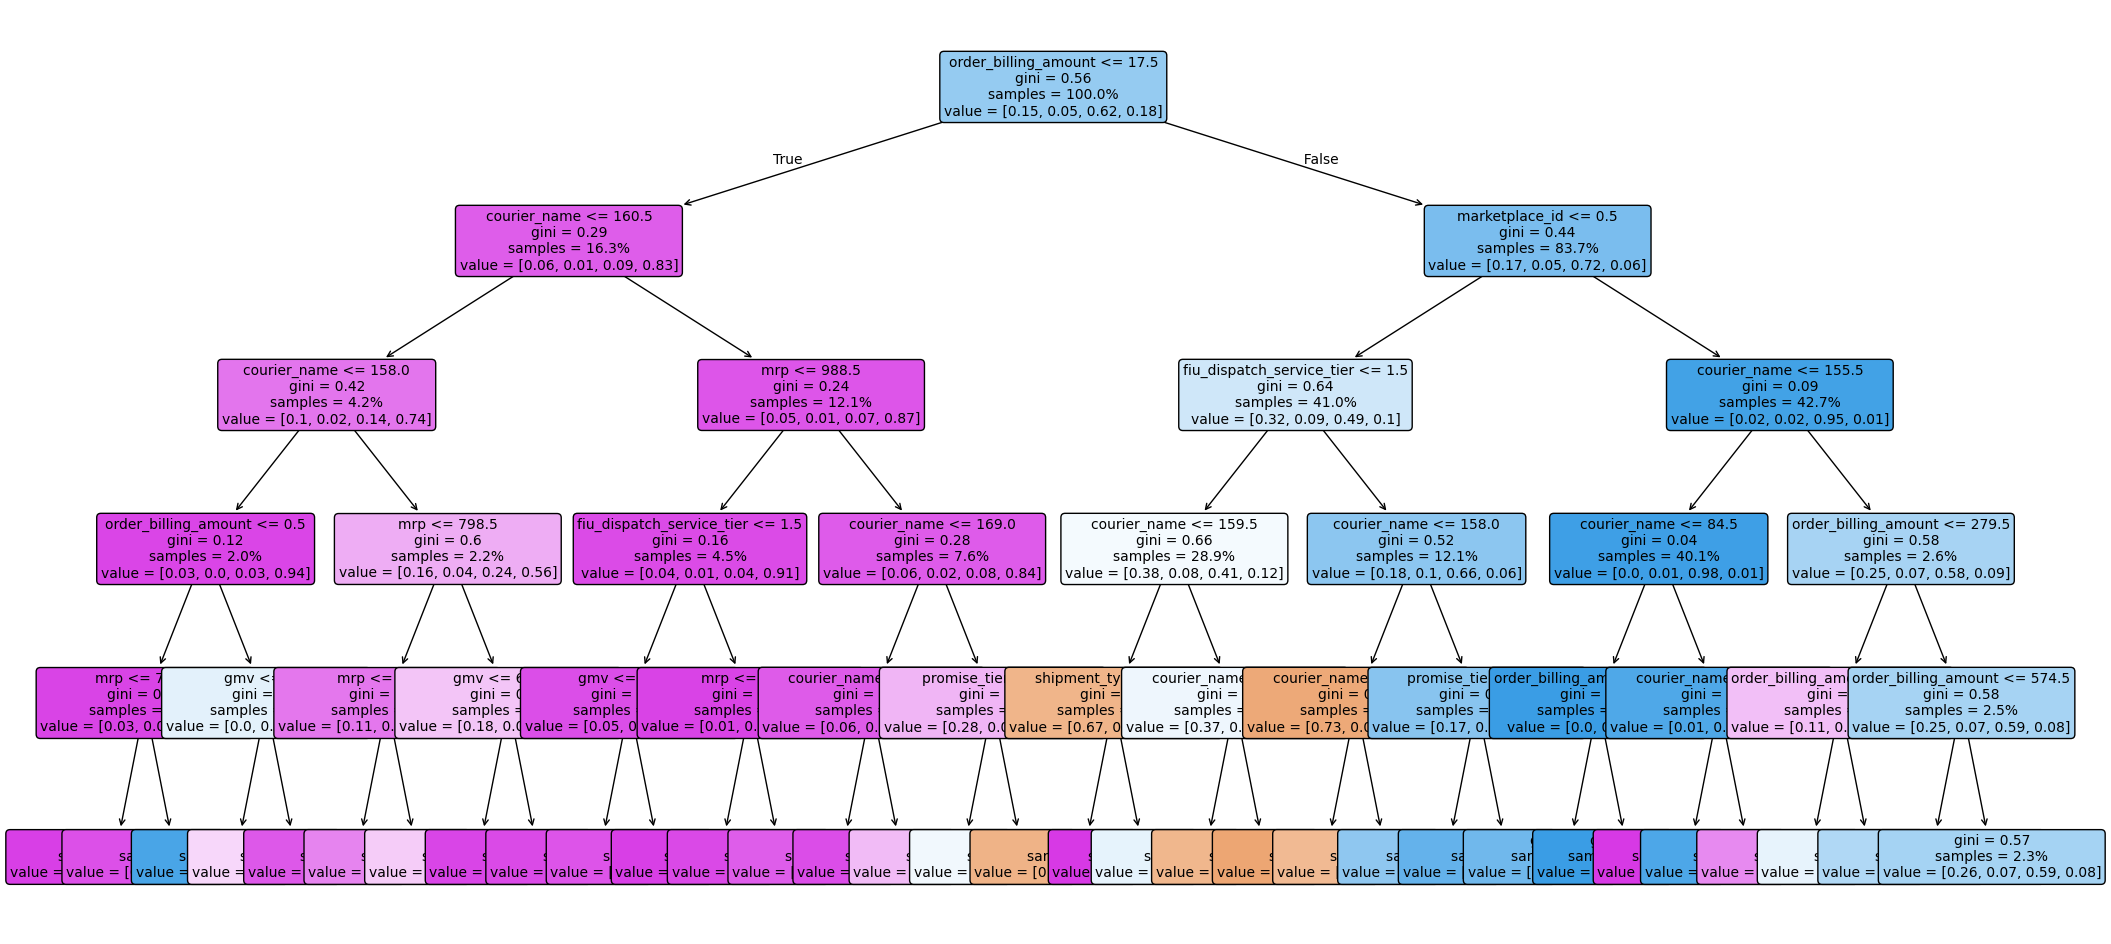

In [50]:
df['listing_price'] = pd.to_numeric(df['listing_price'], errors='coerce')
df['mrp'] = pd.to_numeric(df['mrp'], errors='coerce')
df['sla_in_days'] = pd.to_numeric(df['sla_in_days'], errors= 'coerce')

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object', 'category', 'bool']).columns:
    df[col] = df[col].fillna('Unknown')

cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X_class = df.drop(columns=['promise_breach', 'sla_in_days'])
y_class = df['promise_breach']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size = 0.2, random_state=42)
#clf = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(Xc_train, yc_train)
yc_preds = clf.predict(Xc_test)

print("Classification Accuracy:", accuracy_score(yc_test, yc_preds))
print(classification_report(yc_test, yc_preds))

plt.figure(figsize=(25,12))
tree.plot_tree(
    clf,
    feature_names=X_class.columns,
    #class_names=[str(c) for c in np.unique(y_class)],
    filled=True,
    rounded=True,
    proportion=True,
    #impurity=True,
    precision=2,
    fontsize=10
)
plt.show()

Regressor R2: 0.6893506627347574
Regression MAE: 1.1143474433178946


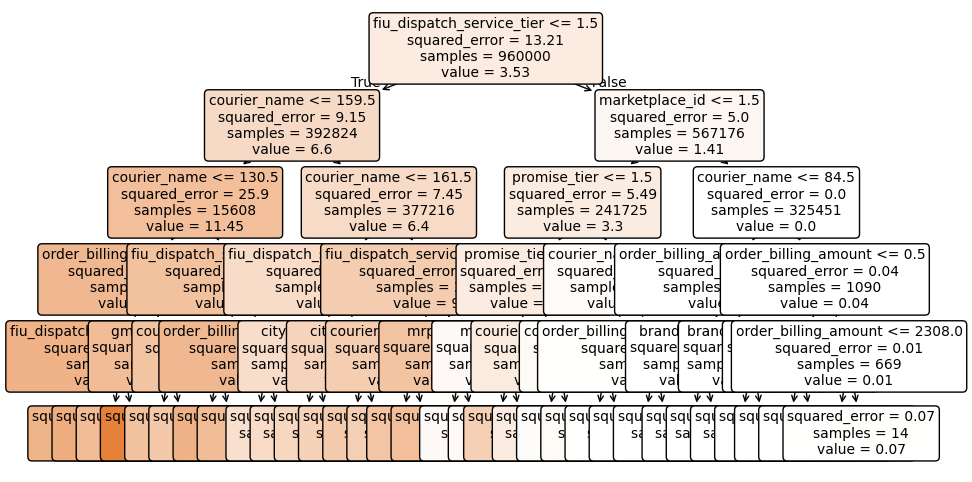

In [45]:
X_reg = df.drop(columns=['sla_in_days', 'promise_breach'])
y_reg = df['sla_in_days']

Xr_train, Xr_test, yr_train, yr_test=train_test_split(X_reg, y_reg, test_size = 0.2, random_state=42)

reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(Xr_train, yr_train)
yr_preds = reg.predict(Xr_test)

print(f"Regressor R2:", r2_score(yr_test, yr_preds))
print(f"Regression MAE:", mean_absolute_error(yr_test, yr_preds))

plt.figure(figsize=(10,6))
tree.plot_tree(
    reg,
    feature_names=X_reg.columns,
    #class_names = [str(c) for c in np.unique(y_class)],
    filled=True,
    rounded=True,
    #proportion=True,
    #impurity=True,
    precision=2,
    fontsize=10
    )
plt.show()